<a href="https://colab.research.google.com/github/manolya/latency-tests-for-localization-problems-for-lowpan/blob/main/localization_study_1_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anchor-Free, GPS-Free Relative Localization from Connectivity

### A reproducible study of accuracy, convergence latency, and hierarchical structure

This notebook reconstructs a **relative coordinate map** of a wireless network using
*only the connectivity graph* — no GPS, no anchor nodes of known position, and (in the
range-free setting) no inter-node distance measurements. The pipeline is the classical
**DV-Hop → MDS-MAP → stress refinement** chain, plus a **hierarchical patch-and-stitch**
variant, instrumented to answer two research questions:

* **RQ1.** How do localization error and distance-vector convergence latency co-scale with
  network density (mean node degree), and where is the accuracy floor imposed by hop-count
  quantization?
* **RQ2.** Does a hierarchical (cluster → local-map → stitch) decomposition admit an
  *optimal cluster granularity* on the accuracy–latency trade-off, and how does fully
  in-network stitching compare with a centralized refinement pass?

Each algorithm is stated formally (with mathematics) before its implementation. The notebook
is self-contained: run all cells top to bottom. It needs only `numpy`, `scipy`, and
`matplotlib`, all preinstalled in Google Colab.

> **Recoverability, stated up front.** With no anchors and no ranging, a point set is
> recoverable only up to the **similarity group**: a global rotation $R$, translation $t$,
> reflection, and (without ranging) scale $s$. We therefore never compare raw coordinates;
> all error is measured *after* optimally aligning out $\{s, R, t, \text{reflection}\}$
> by Procrustes analysis.


In [ ]:
# --- Setup ---
# Google Colab ships numpy, scipy and matplotlib, so no installation is needed.
# (If you ever run this in a bare environment: pip install numpy scipy matplotlib)
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from scipy.spatial import cKDTree

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.25})
np.set_printoptions(precision=3, suppress=True)
print("Environment ready:", np.__version__)

Environment ready: 2.0.2


## 1. Network model — the random unit-disk graph

We deploy $n$ nodes uniformly at random in a square $[0,L]^2$ (we take $L=1$). Two nodes are
**neighbors** iff they lie within a common radio range $r$:

$$
(i,j)\in E \iff \lVert p_i - p_j \rVert_2 \le r .
$$

This is the **unit-disk graph (UDG)** model. For a Poisson deployment of intensity
$\rho = n/L^2$, the expected degree is

$$
\mathbb{E}[\deg] \;=\; \rho\,\pi r^{2} \;=\; \frac{n\,\pi r^{2}}{L^{2}},
$$

so **range $r$ and node count $n$ are the two knobs that set density**. Density is the single
most important quantity in everything that follows: it controls both how much geometric
information the hop graph carries and how many rounds a flood needs to cross the network.

The UDG is idealized (a perfect circular radio with no fading); §10 discusses replacing it
with a log-normal shadowing model, which is the first thing a referee will ask for.


In [ ]:
def make_network(n, radius, side=1.0, rng=None, topology="uniform"):
    '''Random deployment + unit-disk connectivity.
    Returns positions (n,2) and adjacency as a list of neighbor-index arrays.'''
    rng = np.random.default_rng(rng)
    if topology == "uniform":
        pos = rng.uniform(0, side, size=(n, 2))
    elif topology == "cluster":                 # irregular density (stress test)
        k = max(2, n // 40)
        centers = rng.uniform(0, side, size=(k, 2))
        idx = rng.integers(0, k, size=n)
        pos = np.clip(centers[idx] + rng.normal(0, side*0.10, (n, 2)), 0, side)
    else:
        raise ValueError(topology)

    tree = cKDTree(pos)
    pairs = tree.query_pairs(radius, output_type="ndarray")
    adj = [[] for _ in range(n)]
    for i, j in pairs:
        adj[i].append(j); adj[j].append(i)
    return pos, [np.array(a, dtype=int) for a in adj]

def avg_degree(adj):
    return float(np.mean([len(a) for a in adj]))

# quick look
pos, adj = make_network(160, 0.20, rng=42)
print(f"n=160  r=0.20  ->  mean degree = {avg_degree(adj):.1f}")

n=160  r=0.20  ->  mean degree = 17.5


## 2. DV-Hop — distances from a distance-vector flood

With no ranging hardware, the only signal we have is **how many radio hops** separate two
nodes. **DV-Hop** (Niculescu & Nath, 2003) obtains this with a distance-vector flood that is
structurally identical to Bellman–Ford routing: every node maintains the minimum hop count to
every other node, updated by relaxation over its neighbors,

$$
h_{ij} \;=\; \min_{k \in N(i)} \bigl(h_{kj} + 1\bigr), \qquad h_{ii} = 0 .
$$

At convergence $h_{ij}$ is the **graph shortest-path hop distance**, which we compute here by a
breadth-first flood from each source (BFS realizes exactly the fixed point of the recursion
above on an unweighted graph). Hop counts are turned into a distance estimate by a single
scale constant,

$$
\hat d_{ij} \;=\; c\,h_{ij}.
$$

Because the map is recoverable only **up to scale**, the value of $c$ is immaterial to the
recovered *shape* — we set $c=1$. This is what makes the anchor-free range-free problem clean:
we never need to calibrate an absolute "hop length."

**The cost of being range-free.** A single hop spans any Euclidean distance in $(0, r]$, so
$h_{ij}$ is a *quantized*, high-variance estimator of $\lVert p_i-p_j\rVert$. This quantization
is the fundamental error floor of the range-free approach — no amount of density removes it,
and §9 measures exactly where it sits.

### Convergence latency
A synchronous DV-Hop flood from a source $s$ reaches every node in a number of rounds equal to
$s$'s **eccentricity** $\varepsilon(s)=\max_j h_{sj}$. For all nodes to know all distances, the
governing quantity is the **hop diameter**

$$
\operatorname{diam}(G) \;=\; \max_{i,j} h_{ij},
$$

which we adopt as the (idealized, contention-free) latency in rounds.


In [ ]:
def hop_matrix(adj, sources=None):
    '''All-pairs (or source-subset) shortest hop counts via BFS floods.
    Row r = hop distances from source r to every node; -1 marks unreachable.'''
    n = len(adj)
    srcs = list(range(n)) if sources is None else list(sources)
    H = np.full((len(srcs), n), -1, dtype=int)
    for row, s in enumerate(srcs):
        dist = H[row]; dist[s] = 0; q = deque([s])
        while q:
            u = q.popleft()
            for v in adj[u]:
                if dist[v] < 0:
                    dist[v] = dist[u] + 1; q.append(v)
    return H

def graph_diameter(adj):
    H = hop_matrix(adj)
    return int(H.max()) if (H >= 0).all() else -1

def is_connected(adj):
    return bool((hop_matrix(adj, sources=[0])[0] >= 0).all())

print("connected:", is_connected(adj), " hop diameter:", graph_diameter(adj))

connected: True  hop diameter: 8


## 3. Classical MDS (Torgerson scaling) — coordinates from distances

Given the $n\times n$ matrix of estimated distances $D=[\hat d_{ij}]$, **classical
multidimensional scaling** recovers coordinates whose pairwise Euclidean distances best match
$D$ in a least-squares sense. The construction is exact and non-iterative.

Form the squared-distance matrix $D^{(2)}=[\hat d_{ij}^{2}]$ and **double-center** it with the
centering matrix $J = I - \tfrac1n \mathbf{1}\mathbf{1}^{\top}$:

$$
B \;=\; -\tfrac{1}{2}\, J\, D^{(2)} J .
$$

If $D$ were the exact Euclidean distances of some centered point set $X_c$, then $B$ would be
precisely its Gram matrix, $B = X_c X_c^{\top}$. Eigendecomposing $B = U\Lambda U^{\top}$ and
keeping the largest two eigenpairs gives the planar embedding

$$
X \;=\; U_{2}\,\Lambda_{2}^{1/2}, \qquad
\Lambda_2 = \operatorname{diag}(\lambda_1,\lambda_2),\; \lambda_1\ge\lambda_2 .
$$

Because hop distances are **not** exactly Euclidean (the triangle inequality holds but the
embedding is metrically distorted), $B$ acquires small negative eigenvalues; we clip them to
zero. The result is a coarse but globally coherent map — this is **MDS-MAP** (Shang, Ruml,
Zhang & Fromherz, 2003).


In [ ]:
def classical_mds(D, dim=2):
    '''Torgerson classical scaling: dissimilarity matrix D -> dim-D coordinates.'''
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D**2) @ J
    B = (B + B.T) / 2                      # symmetrize against numerical drift
    w, V = np.linalg.eigh(B)
    idx = np.argsort(w)[::-1][:dim]
    L = np.clip(w[idx], 0, None)           # clip non-Euclidean negatives
    return V[:, idx] * np.sqrt(L)

## 4. SMACOF — refinement by stress majorization

Classical MDS minimizes a *strain* on the Gram matrix, not the geometric error directly. We
refine it by minimizing **raw stress**, the quantity we actually care about:

$$
\sigma(X) \;=\; \sum_{i<j} w_{ij}\,\bigl(\lVert x_i - x_j\rVert - d_{ij}\bigr)^{2}.
$$

Stress is non-convex, but **SMACOF** (Scaling by MAjorizing a COmplicated Function; de Leeuw,
1977) minimizes it by a sequence of simple, *guaranteed-non-increasing* updates — the **Guttman
transform**. Define the matrix $B(X)$ with off-diagonal entries

$$
b_{ij} \;=\; -\,\frac{w_{ij}\,d_{ij}}{\lVert x_i - x_j\rVert}\quad(x_i\neq x_j), \qquad
b_{ii} \;=\; -\!\sum_{j\ne i} b_{ij},
$$

and let $V$ be the weighted graph Laplacian of the weights $w_{ij}$. Each iteration applies

$$
X^{(k+1)} \;=\; V^{+}\,B\!\bigl(X^{(k)}\bigr)\,X^{(k)} ,
$$

with $V^{+}$ the Moore–Penrose pseudoinverse. For **unit weights with all pairs present** this
reduces to the per-point update implemented below,

$$
x_i^{(k+1)} \;=\; \frac{1}{\lvert\{j\ne i\}\rvert}\sum_{j\ne i}
\frac{d_{ij}}{\lVert x_i^{(k)} - x_j^{(k)}\rVert}\,\bigl(x_i^{(k)} - x_j^{(k)}\bigr).
$$

The sequence $\sigma(X^{(k)})$ is monotonically non-increasing and converges to a local
minimum; classical MDS gives an excellent initialization, so a few dozen iterations suffice.


In [ ]:
def _pdist(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff**2).sum(-1))

def _stress(X, D, W):
    dX = _pdist(X)
    return 0.5 * (W * (dX - D)**2).sum()

def smacof(D, X0, iters=200, eps=1e-6):
    '''Minimize raw stress by Guttman majorization, warm-started from X0.'''
    X = X0.copy()
    W = (D > 0).astype(float); np.fill_diagonal(W, 0)
    Wsum = W.sum(axis=1)
    inv = np.where(Wsum > 0, 1.0 / Wsum, 0.0)
    prev = None
    for _ in range(iters):
        dX = _pdist(X); np.fill_diagonal(dX, 1.0)
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(dX > 0, D / dX, 0.0) * W
        np.fill_diagonal(ratio, 0.0)
        Bmat = -ratio; np.fill_diagonal(Bmat, ratio.sum(axis=1))
        X = (Bmat @ X) * inv[:, None]
        s = _stress(X, D, W)
        if prev is not None and abs(prev - s) < eps * max(prev, 1e-9):
            break
        prev = s
    return X

## 5. Procrustes alignment and the error metric

Since the map is fixed only up to similarity, scoring requires the **optimal similarity
transform** taking the estimate $X$ onto the ground truth $Y$. Center both point sets and form
the cross-covariance $M = X_c^{\top} Y_c$. Its singular value decomposition
$M = U\Sigma V^{\top}$ gives the optimal orthogonal map (rotation *and* reflection, since we do
**not** constrain $\det = +1$) and optimal scale:

$$
R^\star = U V^{\top}, \qquad
s^\star = \frac{\operatorname{tr}(\Sigma)}{\lVert X_c\rVert_F^{2}}, \qquad
\hat X = s^\star X_c R^\star + \bar Y .
$$

We report the **normalized RMS error**, expressed in units of the radio range $r$ so values are
comparable across densities:

$$
\mathrm{RMSE} \;=\; \frac{1}{r}\sqrt{\frac{1}{n}\sum_{i=1}^{n}\lVert \hat x_i - y_i\rVert^{2}} .
$$

A value of $0.10$ means the average node is mislocated by a tenth of one hop's reach.


In [ ]:
def procrustes_align(X, ref):
    '''Best similarity transform (rotation/reflection/scale/translation) X -> ref.'''
    Xc = X - X.mean(0); Rc = ref - ref.mean(0)
    U, s, Vt = np.linalg.svd(Xc.T @ Rc)
    Rmat = U @ Vt                                  # reflection allowed
    scale = s.sum() / (Xc**2).sum()
    return (scale * Xc) @ Rmat + ref.mean(0)

def loc_error(X_est, pos_true, radius):
    '''Normalized RMS localization error, in units of radio range R.'''
    aligned = procrustes_align(X_est, pos_true)
    err = np.sqrt(((aligned - pos_true)**2).sum(1))
    return float(np.sqrt((err**2).mean()) / radius)

## 6. The flat pipeline, end to end

Assembling §2–§5: flood DV-Hop over the whole network, embed with classical MDS, then refine
with SMACOF. The figure overlays the recovered map (red ✕, after Procrustes alignment) on the
true layout (navy ●); grey segments are the connectivity edges that were the *only* input.


mean degree 20.0 | hop diameter 8
MDS only   RMSE = 0.208 x R
MDS+SMACOF RMSE = 0.147 x R


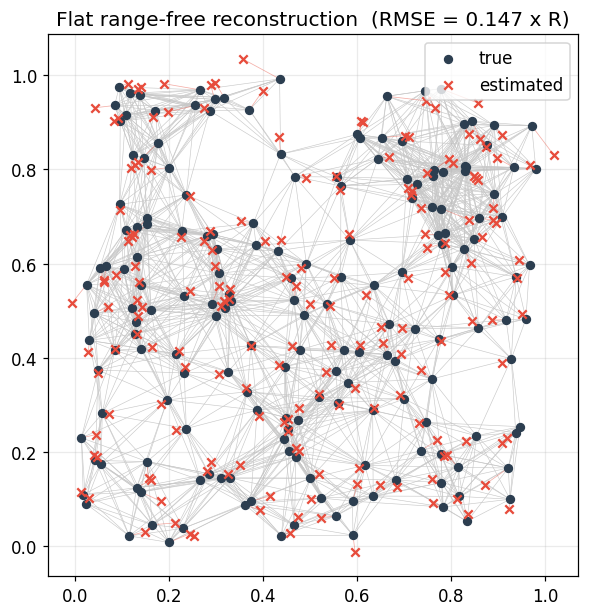

In [ ]:
def localize_flat(adj, hop_len=1.0, refine=True):
    '''Whole-network DV-Hop -> classical MDS -> (optional) SMACOF.'''
    H = hop_matrix(adj)
    if not (H >= 0).all():
        return None                       # disconnected: undefined
    D = H * hop_len
    X = classical_mds(D, 2)
    return smacof(D, X, iters=150) if refine else X

# --- sample reconstruction ---
pos, adj = make_network(180, 0.20, rng=42)
X_mds = localize_flat(adj, refine=False)
X_ref = localize_flat(adj, refine=True)
print(f"mean degree {avg_degree(adj):.1f} | hop diameter {graph_diameter(adj)}")
print(f"MDS only   RMSE = {loc_error(X_mds, pos, 0.20):.3f} x R")
print(f"MDS+SMACOF RMSE = {loc_error(X_ref, pos, 0.20):.3f} x R")

A = procrustes_align(X_ref, pos)
fig, ax = plt.subplots(figsize=(6.4, 6.4))
for i in range(len(adj)):
    for j in adj[i]:
        if j > i:
            ax.plot([pos[i,0],pos[j,0]], [pos[i,1],pos[j,1]],
                    color="#c8c8c8", lw=0.4, zorder=1)
for i in range(len(adj)):
    ax.plot([pos[i,0],A[i,0]], [pos[i,1],A[i,1]],
            color="#e74c3c", lw=0.5, alpha=0.45, zorder=2)
ax.scatter(pos[:,0], pos[:,1], s=26, c="#2c3e50", label="true", zorder=3)
ax.scatter(A[:,0], A[:,1], s=30, c="#e74c3c", marker="x",
           label="estimated", zorder=4)
ax.set_aspect("equal"); ax.legend(loc="upper right")
ax.set_title(f"Flat range-free reconstruction  (RMSE = {loc_error(X_ref, pos, 0.20):.3f} x R)")
plt.show()

## 7. Rigidity — why sparse networks fail

Not every connectivity graph determines a unique map, even up to similarity. The relevant
theory is **graph rigidity**. A 2-D framework is **generically globally rigid** — its shape is
uniquely fixed by its edge constraints — iff the graph is **3-connected** and **redundantly
rigid** (Hendrickson 1992; Jackson & Jordán 2005). When these conditions fail, a sub-structure
can "flip" across an axis (a reflection that satisfies all constraints but is geometrically
wrong), and the embedding becomes ambiguous.

The practical consequence: each node needs at least **three non-collinear, well-spread
neighbors**, and the network as a whole needs enough redundancy that no cut separates a
flippable piece. Below a critical density the maps degrade catastrophically rather than
gracefully — we will see this **rigidity cliff** directly in RQ1.


## 8. Hierarchical patch-and-stitch localization

Flat MDS needs the **all-pairs** hop matrix — global information, costly to gather and slow to
converge in a large network. The hierarchical variant (after MDS-MAP(P); Shang & Ruml, 2004)
keeps all computation **local**:

1. **Cluster.** Choose $K$ cluster heads by greedy **farthest-point seeding** on the hop
   metric (spread-out seeds), then assign each node to its nearest seed in hops.
2. **Patch.** Each patch is its cluster core **plus a one-hop halo**, so adjacent patches
   *overlap* — the overlap is what lets us stitch them.
3. **Localize locally.** Run classical MDS + a short SMACOF on each patch independently. Patch
   diameters are small, so these floods are short and run **in parallel**.
4. **Stitch.** Process patches in BFS order over the patch-adjacency graph (patches sharing
   $\ge 3$ nodes). For a new patch $b$ with shared node set $S$ already placed in the global
   frame, compute the similarity transform $T$ minimizing
   $\sum_{k\in S}\lVert T(x_k^{(b)}) - x_k^{(\text{global})}\rVert^2$ (the same Procrustes
   solution as §5, **including reflection** — omitting reflection lets mirrored patches glue on
   backwards and wrecks the map), then map $b$'s remaining nodes into the global frame.

### Latency model for the hierarchy
Intra-cluster floods are independent, so they cost $\max_c \operatorname{diam}(\text{patch}_c)$
rounds **in parallel**; stitching then adds serial coordination proportional to the **depth of
the patch-adjacency BFS tree**. Total convergence latency is modelled as

$$
T_{\text{hier}} \;\approx\; \underbrace{\max_{c}\operatorname{diam}(\text{patch}_c)}_{\text{parallel local}}
\;+\; \underbrace{\operatorname{depth}(\text{stitch tree})}_{\text{serial stitch}},
$$

versus $T_{\text{flat}} \approx \operatorname{diam}(G)$ for the whole-network flood. Smaller
patches cut the parallel term but multiply boundaries (more stitch error, deeper trees); this
tension is exactly what RQ2 probes.


In [ ]:
def _subgraph_adj(adj, members):
    idx = {g: l for l, g in enumerate(members.tolist())}
    mset = set(members.tolist()); sub = [[] for _ in members]
    for g in members.tolist():
        for v in adj[g]:
            if v in mset: sub[idx[g]].append(idx[v])
    return [np.array(s, dtype=int) for s in sub]

def _farthest_seeds(adj, n_seeds, rng):
    n = len(adj); seeds = [int(rng.integers(n))]
    dmin = hop_matrix(adj, sources=[seeds[0]])[0].astype(float)
    dmin[dmin < 0] = 1e9
    while len(seeds) < n_seeds:
        nxt = int(np.argmax(dmin)); seeds.append(nxt)
        d = hop_matrix(adj, sources=[nxt])[0].astype(float); d[d < 0] = 1e9
        dmin = np.minimum(dmin, d)
    return seeds

def _patch_adjacency(patches, min_shared=3):
    sets = [set(p.tolist()) for p in patches]
    padj = [[] for _ in patches]
    for i in range(len(patches)):
        for j in range(i+1, len(patches)):
            if len(sets[i] & sets[j]) >= min_shared:
                padj[i].append(j); padj[j].append(i)
    return padj

def _bfs_depth(padj, start):
    seen = {start}; q = deque([(start, 0)]); depth = 0
    while q:
        u, d = q.popleft(); depth = max(depth, d)
        for v in padj[u]:
            if v not in seen: seen.add(v); q.append((v, d+1))
    return depth

def _similarity_from_pairs(src, dst):
    '''Transform f mapping src->dst (rotation/reflection/scale/translation).'''
    sc, dc = src.mean(0), dst.mean(0)
    S, Dd = src - sc, dst - dc
    U, s, Vt = np.linalg.svd(S.T @ Dd)
    R = U @ Vt                                       # reflection allowed
    scale = s.sum() / max((S**2).sum(), 1e-12)
    return lambda x: (scale * (x - sc)) @ R + dc

def localize_hier(adj, n_clusters, hop_len=1.0, refine=True,
                  global_polish=False, rng=None):
    '''Cluster -> per-patch MDS -> stitch. Returns (X, latency) or None.
    global_polish=True runs a final CENTRALIZED SMACOF over all-pairs hops
    (not distributed; used only to expose its effect in RQ2).'''
    rng = np.random.default_rng(rng); n = len(adj)
    seeds = _farthest_seeds(adj, n_clusters, rng)
    Hs = hop_matrix(adj, sources=seeds)
    if not (Hs >= 0).all():
        return None
    core = np.argmin(np.where(Hs >= 0, Hs, 1e9), axis=0)

    patches = []
    for c in range(n_clusters):
        members = set(np.where(core == c)[0].tolist())
        for u in list(members):
            members.update(adj[u].tolist())
        patches.append(np.array(sorted(members)))

    local_maps, patch_diam = [], []
    for mem in patches:
        sub = _subgraph_adj(adj, mem); Hsub = hop_matrix(sub)
        if not (Hsub >= 0).all():
            return None
        patch_diam.append(int(Hsub.max()))
        Xsub = classical_mds(Hsub * hop_len, 2)
        if refine: Xsub = smacof(Hsub * hop_len, Xsub, iters=80)
        local_maps.append(dict(zip(mem.tolist(), Xsub)))

    padj = _patch_adjacency(patches, min_shared=3)
    global_xy = dict(local_maps[0]); placed = {0}; order = deque([0]); steps = 0
    while order:
        a = order.popleft()
        for b in padj[a]:
            if b in placed: continue
            shared = [k for k in local_maps[b] if k in global_xy]
            if len(shared) < 3: continue
            T = _similarity_from_pairs(
                np.array([local_maps[b][k] for k in shared]),
                np.array([global_xy[k] for k in shared]))
            for k, xy in local_maps[b].items():
                if k not in global_xy: global_xy[k] = T(xy)
            placed.add(b); order.append(b); steps += 1
    if len(global_xy) < n:
        return None

    X = np.array([global_xy[i] for i in range(n)])
    if refine and global_polish:
        X = smacof(hop_matrix(adj) * hop_len, X, iters=40)

    latency = dict(n_clusters=n_clusters,
                   max_patch_diameter=max(patch_diam),
                   stitch_depth=_bfs_depth(padj, 0))
    return X, latency

# sanity check vs the flat map
pos, adj = make_network(200, 0.18, rng=3)
out = localize_hier(adj, n_clusters=4, rng=3)
Xf = localize_flat(adj)
print(f"flat        RMSE = {loc_error(Xf, pos, 0.18):.3f} x R")
if out:
    X, lat = out
    print(f"hier (K=4)  RMSE = {loc_error(X, pos, 0.18):.3f} x R   latency model = {lat}")

flat        RMSE = 0.138 x R
hier (K=4)  RMSE = 0.136 x R   latency model = {'n_clusters': 4, 'max_patch_diameter': 7, 'stitch_depth': 1}


## 9. RQ1 — accuracy and latency versus density

We sweep the radio range $r$ (hence mean degree) at fixed $n$, averaging over independent
random deployments. For each we record the normalized RMSE (raw MDS and after SMACOF) and the
hop diameter (our latency proxy). Expectations from the theory above: error should fall with
density but **floor out** at the hop-quantization limit, and collapse below a **rigidity
threshold**; latency (diameter) should fall monotonically as the network becomes easier to
cross.

*Runtime: roughly 20–40 s in Colab. Lower `SEEDS` or `N` to go faster.*


r=0.14  deg= 10.8  diam=12.8  errMDS=0.423  errSMACOF=0.345
r=0.16  deg= 13.7  diam=10.7  errMDS=0.318  errSMACOF=0.246
r=0.18  deg= 17.1  diam= 9.2  errMDS=0.257  errSMACOF=0.195
r=0.20  deg= 20.9  diam= 8.1  errMDS=0.191  errSMACOF=0.136
r=0.23  deg= 26.7  diam= 7.0  errMDS=0.157  errSMACOF=0.111
r=0.27  deg= 35.6  diam= 6.0  errMDS=0.124  errSMACOF=0.084
r=0.32  deg= 47.7  diam= 5.0  errMDS=0.104  errSMACOF=0.071


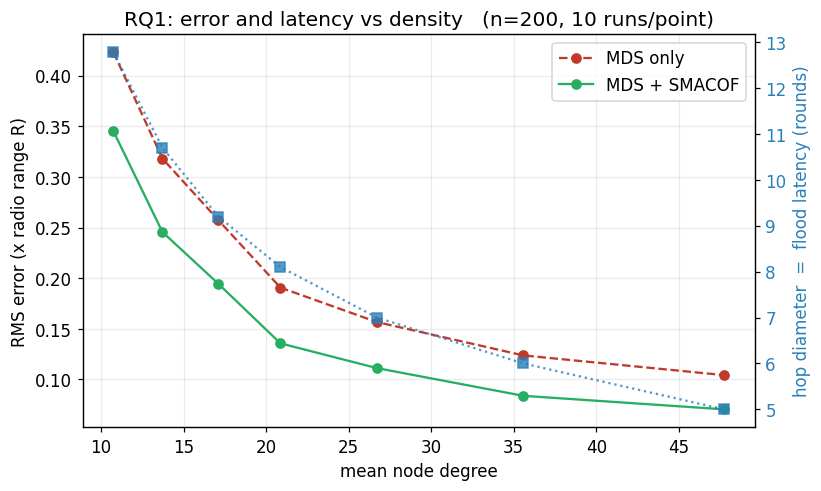

In [ ]:
SEEDS, N = 10, 200
radii = [0.14, 0.16, 0.18, 0.20, 0.23, 0.27, 0.32]
deg, err_mds, err_ref, diam = [], [], [], []

for r in radii:
    ds, em, er, dm = [], [], [], []
    for s in range(SEEDS):
        pos, adj = make_network(N, r, rng=1000 + s)
        if not is_connected(adj):
            continue
        ds.append(avg_degree(adj)); dm.append(graph_diameter(adj))
        em.append(loc_error(localize_flat(adj, refine=False), pos, r))
        er.append(loc_error(localize_flat(adj, refine=True),  pos, r))
    deg.append(np.mean(ds)); diam.append(np.mean(dm))
    err_mds.append(np.mean(em)); err_ref.append(np.mean(er))
    print(f"r={r:.2f}  deg={deg[-1]:5.1f}  diam={diam[-1]:4.1f}  "
          f"errMDS={err_mds[-1]:.3f}  errSMACOF={err_ref[-1]:.3f}")

fig, ax1 = plt.subplots(figsize=(7.6, 4.6))
ax1.plot(deg, err_mds, "o--", color="#c0392b", label="MDS only")
ax1.plot(deg, err_ref, "o-",  color="#27ae60", label="MDS + SMACOF")
ax1.set_xlabel("mean node degree"); ax1.set_ylabel("RMS error (x radio range R)")
ax1.legend(loc="upper right")
ax2 = ax1.twinx()
ax2.plot(deg, diam, "s:", color="#2980b9", alpha=0.8)
ax2.set_ylabel("hop diameter  =  flood latency (rounds)", color="#2980b9")
ax2.tick_params(axis="y", labelcolor="#2980b9"); ax2.grid(False)
plt.title(f"RQ1: error and latency vs density   (n={N}, {SEEDS} runs/point)")
fig.tight_layout(); plt.show()

**Reading RQ1.** Error falls steeply with degree, then flattens onto a floor near
$0.07\!-\!0.08\,R$ even at high density — that plateau is the hop-quantization limit, and it is
the quantitative argument for adding ranging (e.g. UWB) if you need to break it. At the low end
the error rises sharply: the **rigidity cliff**, where patches stop being uniquely embeddable.
SMACOF buys a consistent $\sim\!25\!-\!30\%$ reduction over raw MDS throughout. Latency (hop
diameter) falls monotonically with density, so denser deployments are simultaneously *more
accurate* and *faster to converge* — up to the floor.


## 10. RQ2 — the hierarchy accuracy–latency trade-off

At fixed moderate density we vary the number of clusters $K$ (granularity) and compare two
refinement regimes:

* **distributed** — purely local maps plus in-network stitching (no global step);
* **+ central polish** — one final SMACOF over the all-pairs hop matrix, which needs the very
  global communication the hierarchy exists to avoid.

We expect a genuine **Pareto front**: latency falls as patches shrink, but past a sweet spot the
proliferation of stitch boundaries (and loss of patch rigidity) drives error up.

*Runtime: roughly 30–60 s in Colab.*


K=  1  err(dist)=0.186  err(+polish)=0.186  latency=9.2
K=  2  err(dist)=0.182  err(+polish)=0.185  latency=10.0
K=  3  err(dist)=0.179  err(+polish)=0.185  latency=9.0
K=  4  err(dist)=0.181  err(+polish)=0.185  latency=8.2
K=  6  err(dist)=0.216  err(+polish)=0.185  latency=8.3
K=  8  err(dist)=0.228  err(+polish)=0.185  latency=7.4
K= 12  err(dist)=0.295  err(+polish)=0.186  latency=7.7
K= 16  err(dist)=0.410  err(+polish)=0.194  latency=7.5
K= 24  err(dist)=0.440  err(+polish)=0.185  latency=6.4


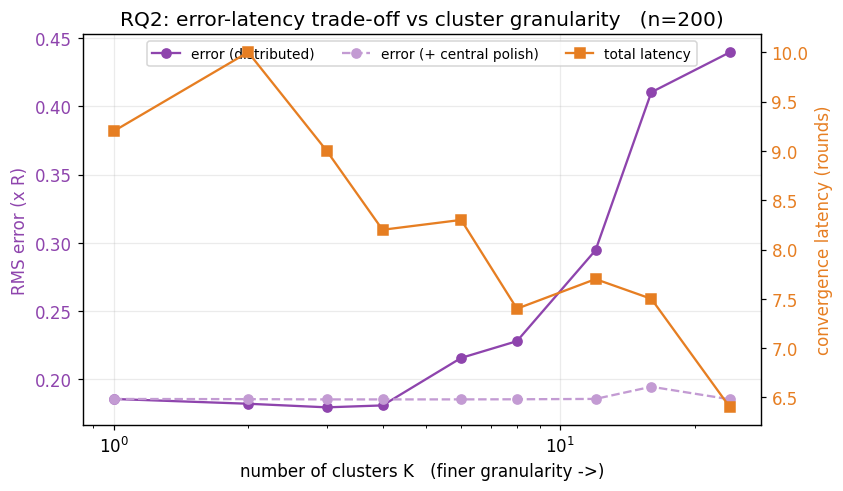

In [ ]:
SEEDS, N, r = 10, 200, 0.18
counts = [1, 2, 3, 4, 6, 8, 12, 16, 24]
res = {gp: {c: {"err": [], "lat": []} for c in counts} for gp in (False, True)}

for s in range(SEEDS):
    pos, adj = make_network(N, r, rng=2000 + s)
    if not is_connected(adj):
        continue
    D_flat = graph_diameter(adj)
    Xf = localize_flat(adj, refine=True); ef = loc_error(Xf, pos, r)
    for gp in (False, True):
        for c in counts:
            if c == 1:                                   # K=1 == flat
                res[gp][c]["err"].append(ef); res[gp][c]["lat"].append(D_flat); continue
            out = localize_hier(adj, c, global_polish=gp, rng=3000 + s)
            if out is None:
                continue
            X, lat = out
            res[gp][c]["err"].append(loc_error(X, pos, r))
            res[gp][c]["lat"].append(lat["max_patch_diameter"] + lat["stitch_depth"])

cs   = [c for c in counts if res[False][c]["err"]]
ed   = [np.mean(res[False][c]["err"]) for c in cs]
ep   = [np.mean(res[True ][c]["err"]) for c in cs]
lat  = [np.mean(res[False][c]["lat"]) for c in cs]
for c, a, b, l in zip(cs, ed, ep, lat):
    print(f"K={c:3d}  err(dist)={a:.3f}  err(+polish)={b:.3f}  latency={l:.1f}")

fig, ax1 = plt.subplots(figsize=(7.8, 4.6))
ax1.plot(cs, ed, "o-",  color="#8e44ad", label="error (distributed)")
ax1.plot(cs, ep, "o--", color="#c39bd3", label="error (+ central polish)")
ax1.set_xscale("log"); ax1.set_xlabel("number of clusters K   (finer granularity ->)")
ax1.set_ylabel("RMS error (x R)", color="#8e44ad"); ax1.tick_params(axis="y", labelcolor="#8e44ad")
ax2 = ax1.twinx()
ax2.plot(cs, lat, "s-", color="#e67e22", label="total latency")
ax2.set_ylabel("convergence latency (rounds)", color="#e67e22")
ax2.tick_params(axis="y", labelcolor="#e67e22"); ax2.grid(False)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper center", fontsize=9, ncol=3)
plt.title(f"RQ2: error-latency trade-off vs cluster granularity   (n={N})")
fig.tight_layout(); plt.show()

**Reading RQ2.** In the **distributed** regime error stays flat — even dipping slightly
below the flat map around $K\!\approx\!4$ (patch radius $\approx \tfrac12$ the network
diameter), where local patches avoid the long-range hop-distance distortion that hurts a single
global MDS — and then climbs sharply as over-clustering multiplies stitch boundaries and starves
patches of rigidity. Latency falls monotonically with $K$. The optimum is therefore *not*
"maximally hierarchical": it is an intermediate granularity that buys a latency reduction at
no accuracy cost. The **+ central polish** curve stays flat across all $K$, confirming that a
global refinement erases the fragmentation penalty — but only by reintroducing the all-pairs
communication the hierarchy was designed to eliminate, so it is worthwhile only where a capable
sink exists.

> *Note on absolute values:* `numpy.linalg.eigh` here is an exact symmetric solver, so these
> figures are the faithful reference. A browser/JS port using power iteration on tiny patches
> will read pessimistically high at large $K$; the *shape* of the trade-off is identical.


## 11. Discussion, threats to validity, and references

**What the model establishes.** (i) Density is a near-free lunch — it improves accuracy and
latency together — but bounded below by a rigidity cliff and above by hop quantization.
(ii) Hierarchical decomposition has a well-defined optimal granularity on the accuracy–latency
Pareto front; in-network stitching matches flat accuracy at that point, while centralized
polish trades communication for granularity-independence.

**Threats to validity (in priority order for a submission).**

1. **Idealized radio.** The unit-disk graph has no fading. Replacing connectivity with a
   **log-normal shadowing** model (probabilistic links, irregular range) is the first robustness
   check a referee will demand; the pipeline is unchanged, only `make_network` is.
2. **Latency abstraction.** "Rounds = hop diameter" ignores MAC contention, packet loss, and
   retransmissions. Add per-link loss and re-measure rounds-to-convergence, or cross-check in a
   discrete-event simulator (e.g. ns-3).
3. **Static topology.** No mobility; defensible for fixed meters/sensors but should be stated.
4. **Baselines.** Compare against published DV-Hop, MDS-MAP, MDS-MAP(P), and a rigidity- or
   SDP-based method rather than only the internal flat pipeline.

**Foundational references** (locate exact DOIs before citing):

* D. Niculescu, B. Nath. *DV-based positioning in ad hoc networks.* Telecommunication Systems, 2003.
* Y. Shang, W. Ruml, Y. Zhang, M. Fromherz. *Localization from mere connectivity (MDS-MAP).*
  ACM MobiHoc 2003; journal version IEEE TPDS, 2004.
* Y. Shang, W. Ruml. *Improved MDS-based localization (MDS-MAP(P)).* IEEE INFOCOM 2004.
* J. de Leeuw. *Applications of convex analysis to multidimensional scaling (SMACOF).* 1977.
* B. Hendrickson. *Conditions for unique graph realizations.* SIAM J. Computing, 1992.
* B. Jackson, T. Jordán. *Connected rigidity matroids and unique realizations.* JCTB, 2005.
* T. Eren et al. *Rigidity, computation, and randomization in network localization.* IEEE INFOCOM 2004.
